# Testing AirGravQC - Example Data

Mark Dransfield

In [1]:
import datetime
start = datetime.datetime.now()
print(start)

2024-08-07 10:51:29.693157


In [2]:
%matplotlib widget
from pathlib import Path

import AirGravQC as qc

In [3]:
# Choose `local_docs` to suit you.
local_docs = "/Users/markdransfield/"
# local_docs = "/Users/markdransfield/Library/Mobile Documents/com~apple~CloudDocs/"

data_root = local_docs + "Documents/GitHub/AirGravQC/examples/SourceData/"

canobieXYZ_file = Path(data_root + r'Canobie.xyz')
canobieHDF_file = canobieXYZ_file.with_suffix('.hdf5')

EastVicXYZ_file = Path(data_root + r'EastVic.xyz')
EastVicHDF_file = EastVicXYZ_file.with_suffix('.hdf5')

EastVicTestXYZ_file = Path(data_root + r'EastVicTest.xyz')
EastVicTestHDF_file = EastVicTestXYZ_file.with_suffix('.hdf5')

EastVicRepXYZ_file = Path(data_root + r'EastVicRepeats.xyz')
EastVicRepHDF_file = EastVicRepXYZ_file.with_suffix('.hdf5')

vintonXYZ_file = Path(data_root + r'VintonDome.xyz')
vintonHDF_file = vintonXYZ_file.with_suffix('.hdf5')

# Sometimes, but not this time, the plan data is in a different directory ...
plan_root = data_root

# We will only use plan data for two projects
canobieXYZ_plan = Path(plan_root + r'CanobiePlan.xyz')
canobieHDF_plan = canobieXYZ_plan.with_suffix('.hdf5')

EastVicXYZ_plan = Path(plan_root + r'EastVicPlan.xyz')
EastVicHDF_plan = EastVicXYZ_plan.with_suffix('.hdf5')

# The following data are used to test ASEG-GDF2 import but are final data
# so have no QC problems and don't contain the fields required for some QC.
# We only use them to create the geoWhizz file and report its contents.
canobie_del_root = r'/Volumes/T7/FalconSurveys/202111_Falcon_Canobie_GA/2022-03-02-FinalsRevised/located/'
canobie_surv_meta = Path(canobie_del_root + r'902212_survey.json')
canobie_data_meta = Path(canobie_del_root + r'902212_data.json')
canobieGDF_file = Path(canobie_del_root + r'902212_AGG.dat')
canobieGDF_whizz = canobieGDF_file.with_suffix('.hdf5')

mag_root = local_docs + "Documents/GitHub/AirGravQC/examples/Airmag_GDF/"

muppetGDF_file = Path(mag_root + r'Example_AeroMag_MuppetTown_2009.dat')
muppet_surv_meta = Path(mag_root + r'MuppetTown_survey.json')
muppet_data_meta = Path(mag_root + r'MuppetTown_data.json')
muppetHDF_file = muppetGDF_file.with_suffix('.hdf5')

### Canobie Data

#### Convert plan XYZ data to geoWhizz, and set metadata

In this example, the plan data file only has the (x,y) locations of the start and end of each line and we have no planned heights. The process is the same as for the acquired survey data `XYZ` file above.

In [ ]:
qc.xyzToHDF(Path(canobieXYZ_plan), projectName='Canobie')
block_name = 'Survey Plan'
qc.updateProject(canobieHDF_plan, acquirer='Xcalibur Multiphysics', blockID=block_name)

In [ ]:
qc.updateCoordFrame(canobieHDF_plan, x='EASTING', y='NORTHING')
qc.updateCoordFrame(canobieHDF_plan, geoDatum='WGS84', projection='UTM', utmz='54')
qc.updateLineAttributes(canobieHDF_plan, line_type='Xcal_can')

In [ ]:
qc.updateChannelAttributes(canobieHDF_plan, 'EASTING', units='m')
qc.updateChannelAttributes(canobieHDF_plan, 'NORTHING', units='m')

#### Summary report of plan data

In [ ]:
qc.reportWhizz(canobieHDF_plan, )

#### Convert measured XYZ data to geoWhizz, and set metadata

> The next step is essential. We need the data in HDF5 geoWhizz format because all the QC functions expect that format. (More on the geoWhizz format in the `AirGravQC` documentation.)

> Geosoft XYZ files generally have only the channel names, and no other metadata. We need the attributes of the data at project level, at line number level, and at data channel level.

In [ ]:
qc.xyzToHDF(Path(canobieXYZ_file), projectName='Canobie')

> Now we demonstrate the use of `updateProject()` to add additional project attributes.

> It also shows the use of `updateCoordFrame()` which keeps track of the coordinate definition and the names of the channels that contain position and time. Many QC routines use position and time, so it saves effort later to have this information in the geoWhizz group attributes.

> Field data are commonly delivered to WGS84, projected to UTM, because that is what GNSS delivers. Transformation to the desired datum happens at the end of the project for the final data.

In [ ]:
block_name = 'Prelim Canobie Data'
qc.updateProject(canobieHDF_file, acquirer='Xcalibur Multiphysics', blockID=block_name)
qc.updateCoordFrame(canobieHDF_file, lat='LATITUDE', lon='LONGITUDE', x='EASTING', y='NORTHING', time='Time_1980', alt='HEIGHT')
qc.updateCoordFrame(canobieHDF_file, geoDatum='WGS84', htDatum='WGS84', projection='UTM', utmz='54')

> The line attributes represent a challenge. Line numbers are usually coded to contain a number of impoprtant attributes: whether the line is a traverse, control, repeat or test line; which segment of a number of segments needed to complete the line, and whether it is a re-flight; and what is the line number of the corresponding planned line number. Each supplier uses a different coding system, and sometimes they will use different codings for different projects (or, worst of all (but vary rare), between staff processing the data on the same project!).

> AirGravQC knows only 3 of these systems so far and this will need expanding. So beware!

In [ ]:
qc.updateLineAttributes(canobieHDF_file, planfile=canobieHDF_plan,
                        line_type='Xcal_can', flight_chan='FLIGHT', date_chan='Date')

> The acquirers of the data supplied a separate text file `Channel Descriptions.txt` with the requisite channel attributes metadata which then had to be entered manually via this series of commands to store it in the geoWhizz file created by `xyzToHDF()`. There is some drudgery involved here which you will have to do for your project.

> I did not enter in the supplied descriptions for the channel attributes so all that is happening here is storing the units for each channel. Units are used in some QC checking. *Could we automate this process by reading channel description files?*

In [ ]:
qc.updateChannelAttributes(canobieHDF_file, 'ANE_TC_2p67', units='eotvos')
qc.updateChannelAttributes(canobieHDF_file, 'AUV_TC_2p67', units='eotvos')
qc.updateChannelAttributes(canobieHDF_file, 'Bearing', units='degrees')
qc.updateChannelAttributes(canobieHDF_file, 'BNE_TC_2p67', units='eotvos')
qc.updateChannelAttributes(canobieHDF_file, 'BUV_TC_2p67', units='eotvos')
qc.updateChannelAttributes(canobieHDF_file, 'CLEARANCE', units='metre')
qc.updateChannelAttributes(canobieHDF_file, 'Date')
qc.updateChannelAttributes(canobieHDF_file, 'DTM', units='metre')
qc.updateChannelAttributes(canobieHDF_file, 'EASTING', units='metre')
qc.updateChannelAttributes(canobieHDF_file, 'FIDUCIAL')
qc.updateChannelAttributes(canobieHDF_file, 'FLIGHT')
qc.updateChannelAttributes(canobieHDF_file, 'gD_Fourier_2p67', units='µm/s/s')
qc.updateChannelAttributes(canobieHDF_file, 'GDD_Fourier_2p67', units='eotvos')
qc.updateChannelAttributes(canobieHDF_file, 'GNE_Fourier_2p67', units='eotvos')
qc.updateChannelAttributes(canobieHDF_file, 'GUV_Fourier_2p67', units='eotvos')
qc.updateChannelAttributes(canobieHDF_file, 'HDOP')
qc.updateChannelAttributes(canobieHDF_file, 'HEIGHT', units='metre')
qc.updateChannelAttributes(canobieHDF_file, 'JOB_ID')
qc.updateChannelAttributes(canobieHDF_file, 'LATITUDE', units='degree')
qc.updateChannelAttributes(canobieHDF_file, 'LINE')
qc.updateChannelAttributes(canobieHDF_file, 'LONGITUDE', units='degree')
qc.updateChannelAttributes(canobieHDF_file, 'Noise_NE', units='eotvos')
qc.updateChannelAttributes(canobieHDF_file, 'Noise_UV', units='eotvos')
qc.updateChannelAttributes(canobieHDF_file, 'NORTHING', units='metre')
qc.updateChannelAttributes(canobieHDF_file, 'NumSats')
qc.updateChannelAttributes(canobieHDF_file, 'PDOP')
qc.updateChannelAttributes(canobieHDF_file, 'T_DD', units='eotvos')
qc.updateChannelAttributes(canobieHDF_file, 'T_NE', units='eotvos')
qc.updateChannelAttributes(canobieHDF_file, 'T_UV', units='µm/s/s')
qc.updateChannelAttributes(canobieHDF_file, 'Time_1980', units='seconds')
qc.updateChannelAttributes(canobieHDF_file, 'Time_Day', units='seconds')
qc.updateChannelAttributes(canobieHDF_file, 'TURBULENCE', units='m/s/s')
qc.updateChannelAttributes(canobieHDF_file, 'VDOP')

#### Summary report of measured data

> Summary report of contents of data file. The `reportWhizz()` code can list attributes of a line via the `line=...` keyword, or a channel via the `channel=...` keyword.

In [5]:
qc.reportWhizz(canobieHDF_file)#, channel='ANE_TC_2p67')

Whizz Version 1.0
    Acquirer: Xcalibur Multiphysics
    BlockID: Prelim Canobie Data
    ProjectName: Canobie

Coordinates
    AltitudeChannel: HEIGHT
    GeoDatum: WGS84
    HeightDatum: WGS84
    LatitudeChannel: LATITUDE
    LongitudeChannel: LONGITUDE
    Projection: UTM
    TimeChannel: Time_1980
    UTMZone: 54
    XChannel: EASTING
    YChannel: NORTHING
6 lines: total distance flown [km] = 360.0

6 lines:
 ['100010.000', '100020.000', '100030.000', '100040.000', '100050.000', '100060.000']

33 channels:
 ['ANE_TC_2p67', 'AUV_TC_2p67', 'BNE_TC_2p67', 'BUV_TC_2p67', 'Bearing', 'CLEARANCE', 'DTM', 'Date', 'EASTING', 'FIDUCIAL', 'FLIGHT', 'GDD_Fourier_2p67', 'GNE_Fourier_2p67', 'GUV_Fourier_2p67', 'HDOP', 'HEIGHT', 'JOB_ID', 'LATITUDE', 'LINE', 'LONGITUDE', 'NORTHING', 'Noise_NE', 'Noise_UV', 'NumSats', 'PDOP', 'TURBULENCE', 'T_DD', 'T_NE', 'T_UV', 'Time_1980', 'Time_Day', 'VDOP', 'gD_Fourier_2p67']


In [ ]:
qc.reportFlights(canobieHDF_file, flightChannel='FLIGHT', detailed=True)

> Sample times should be constant. Here we have one at 0.126 which ought to be checked. Sample distances vary with aircraft ground speed.

In [ ]:
qc.reportSampling(canobieHDF_file)

#### Map showing flown lines against plan.

> This provides a visual check that the lines are in about the right location and shows the amount of the survey flown so far.

In [ ]:
qc.linesMap([canobieHDF_file], whizzPlanFile=canobieHDF_plan)

## Statistics and Grids
<div class="alert alert-block alert-info">
NA
<div>

Gridding and imaging Bearing
6 lines; total number of fids in whizz file = 48583.
    Bearing (mr): min = -10.986009852216796, max = 6.113990147783227.
Processing (x, y, z) = (EASTING, NORTHING, MR_Bearing). MR_Bearing in degrees.


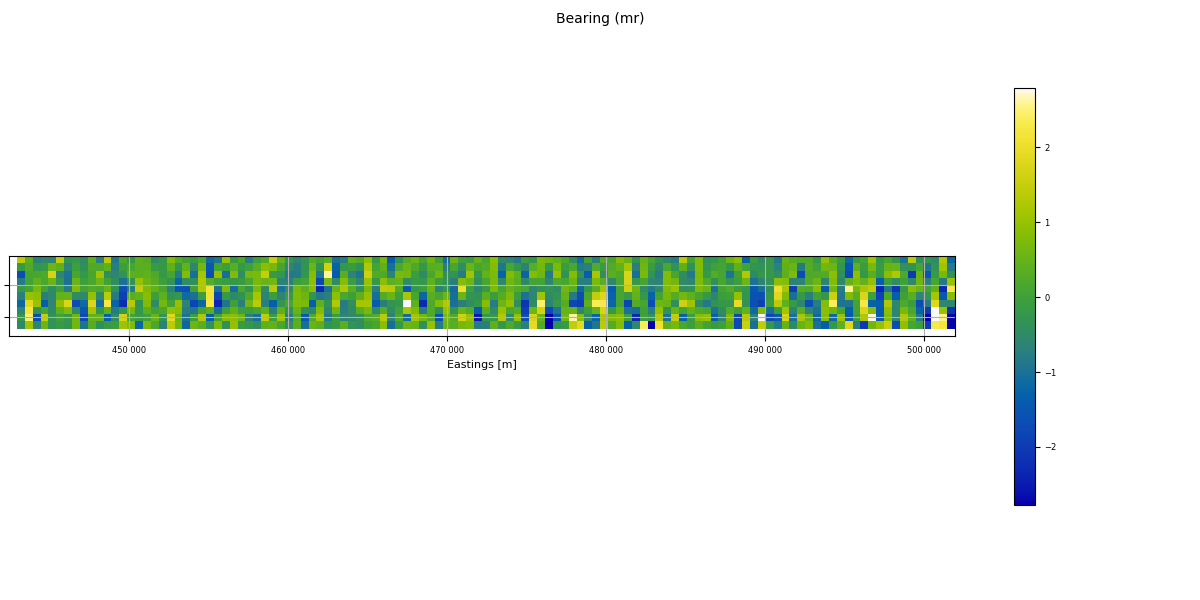

RMS of result = 0.93 degrees
Gridding and imaging CLEARANCE
6 lines; total number of fids in whizz file = 48583.
    CLEARANCE: min = 66.655, max = 329.044.
Processing (x, y, z) = (EASTING, NORTHING, CLEARANCE). CLEARANCE in metre.


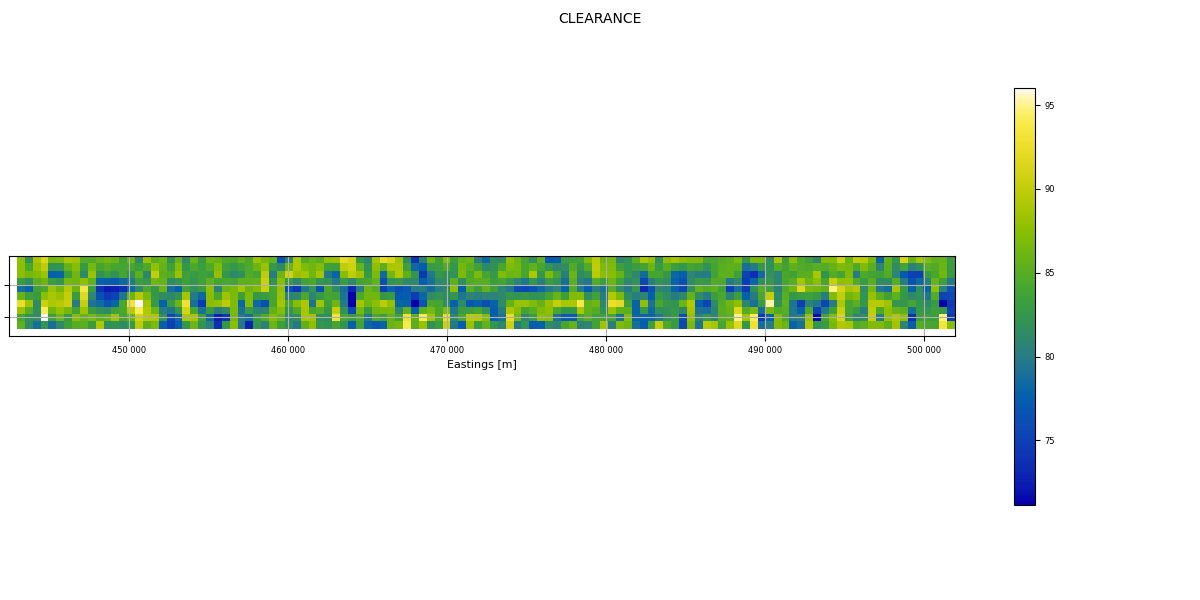

RMS of result = 4.14 metre
Gridding and imaging DTM
6 lines; total number of fids in whizz file = 48583.
    DTM: min = 47.9, max = 76.9.
Processing (x, y, z) = (EASTING, NORTHING, DTM). DTM in metre.


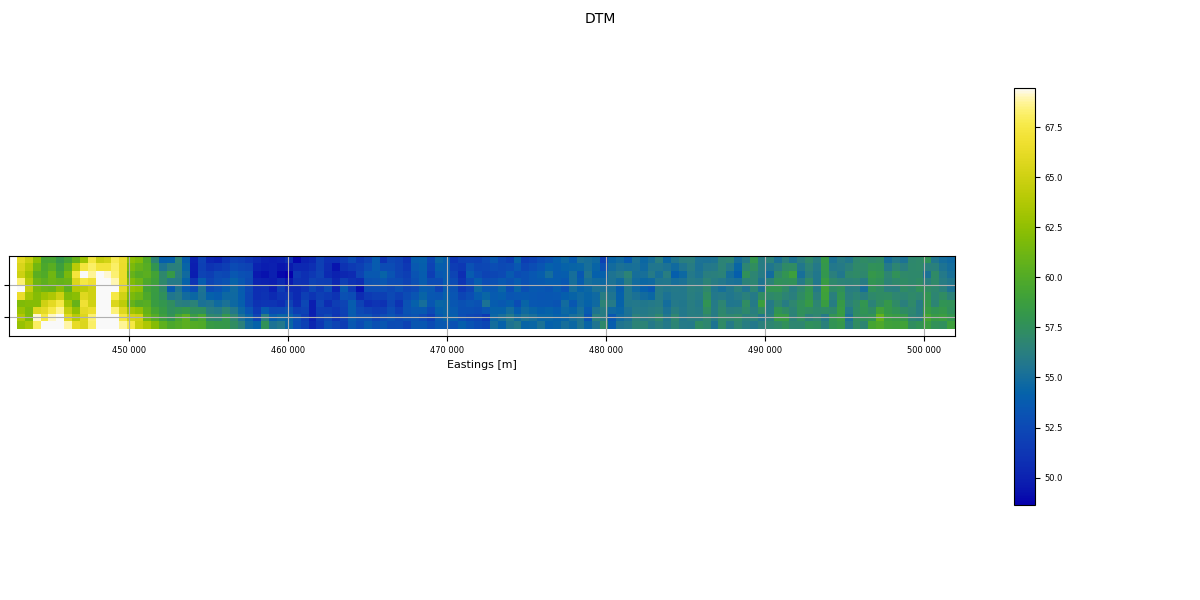

RMS of result = 4.43 metre
Gridding and imaging FLIGHT
6 lines; total number of fids in whizz file = 48583.
    FLIGHT (d1): min = 0.0, max = 0.0.
Processing (x, y, z) = (EASTING, NORTHING, D1_FLIGHT). D1_FLIGHT in .


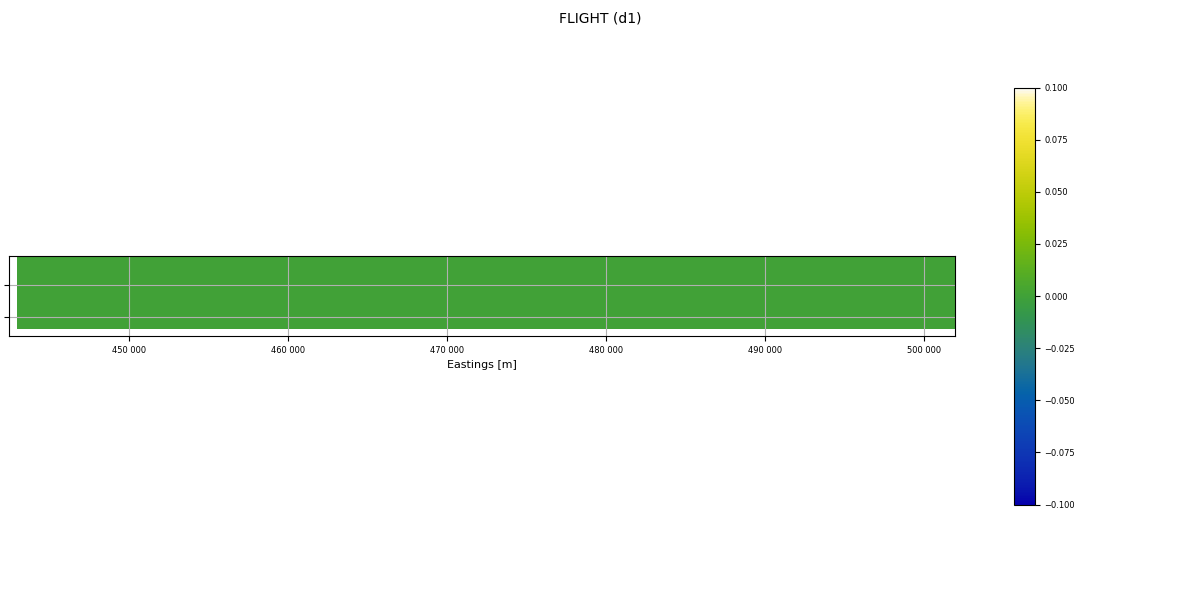

RMS of result = 0.00 
Gridding and imaging GDD_Fourier_2p67
6 lines; total number of fids in whizz file = 48583.
    GDD_Fourier_2p67: min = -29.47, max = 67.3.
Processing (x, y, z) = (EASTING, NORTHING, GDD_Fourier_2p67). GDD_Fourier_2p67 in eotvos.


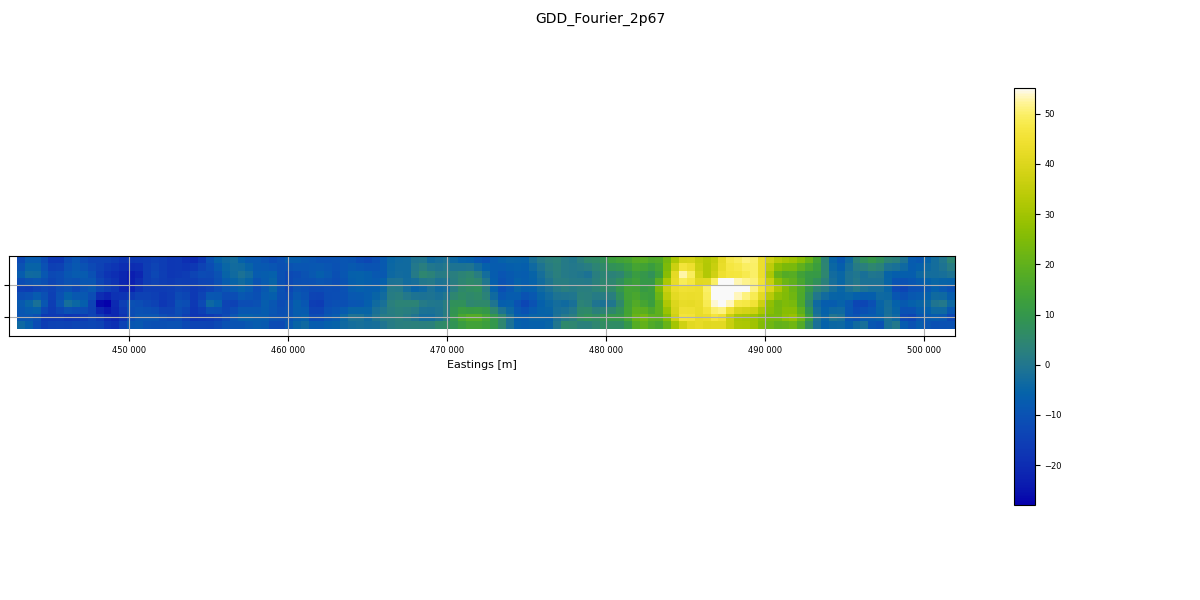

RMS of result = 17.85 eotvos
Gridding and imaging NumSats
6 lines; total number of fids in whizz file = 48583.
    NumSats: min = 8.0, max = 15.0.
Processing (x, y, z) = (EASTING, NORTHING, NumSats). NumSats in .


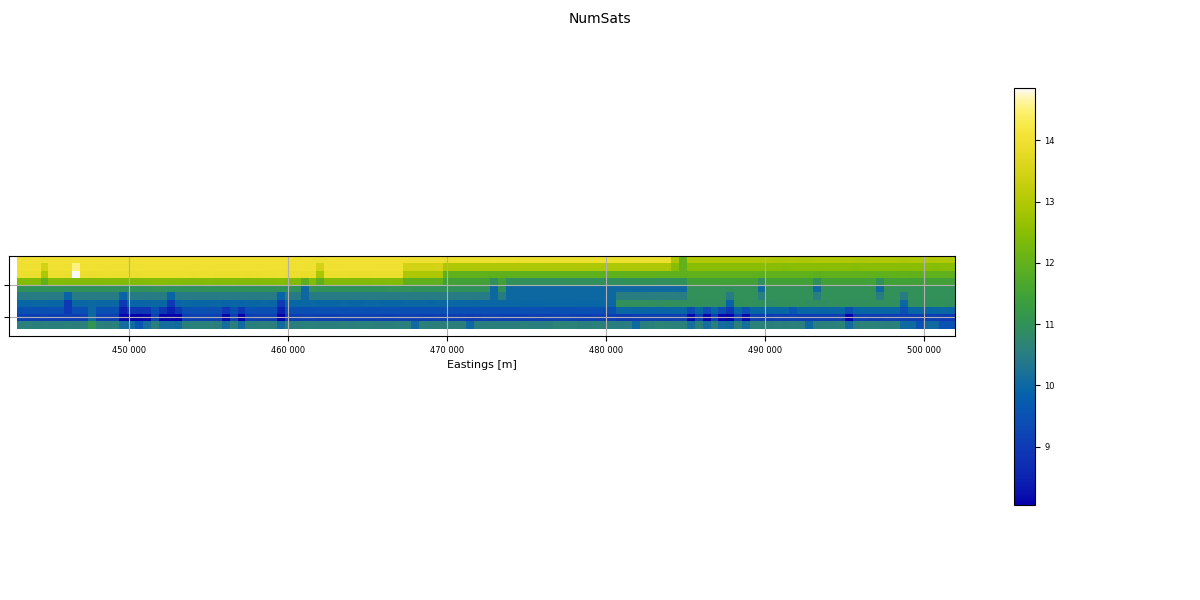

RMS of result = 1.61 
Gridding and imaging T_DD
6 lines; total number of fids in whizz file = 48583.
    T_DD: min = -4.84, max = 14.26.
Processing (x, y, z) = (EASTING, NORTHING, T_DD). T_DD in eotvos.


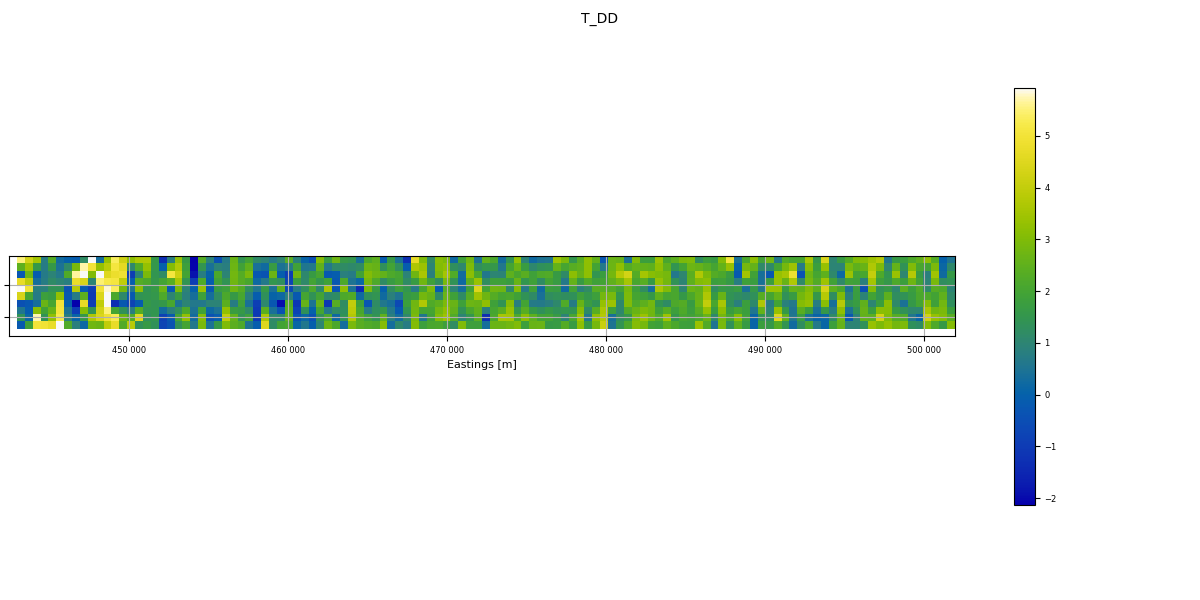

RMS of result = 1.34 eotvos
Gridding and imaging Time_1980
6 lines; total number of fids in whizz file = 48583.
    Time_1980 (d1): min = 0.125, max = 0.12600016593933105.
Processing (x, y, z) = (EASTING, NORTHING, D1_Time_1980). D1_Time_1980 in seconds.


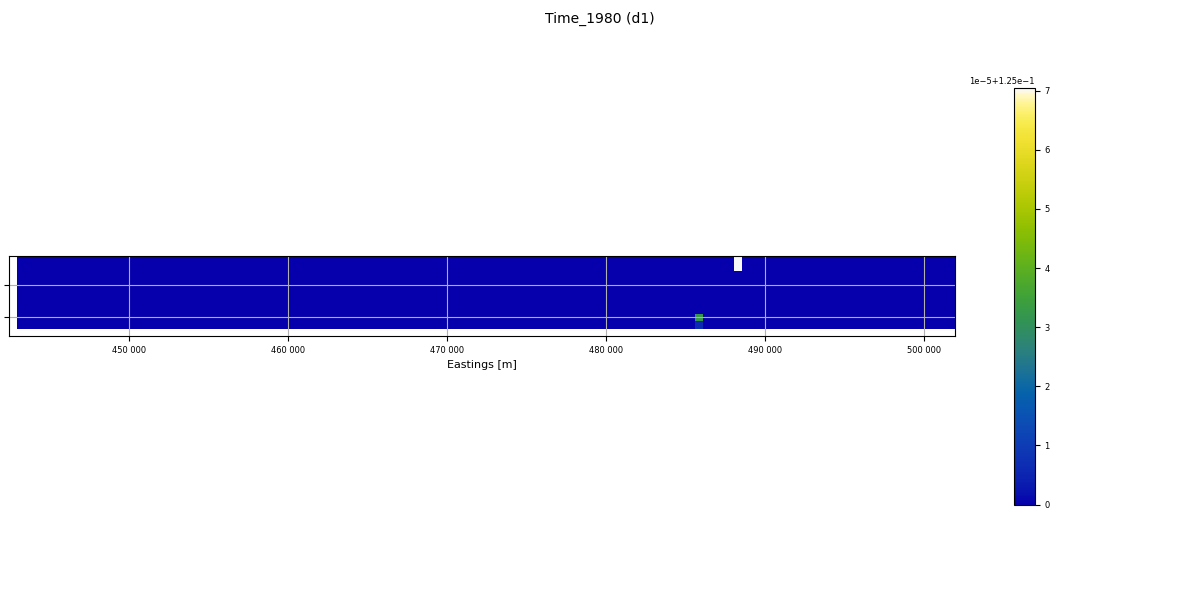

RMS of result = 0.00 seconds
Gridding and imaging gD_Fourier_2p67
6 lines; total number of fids in whizz file = 48583.
    gD_Fourier_2p67: min = -10.92, max = 24.71.
Processing (x, y, z) = (EASTING, NORTHING, gD_Fourier_2p67). gD_Fourier_2p67 in µm/s/s.


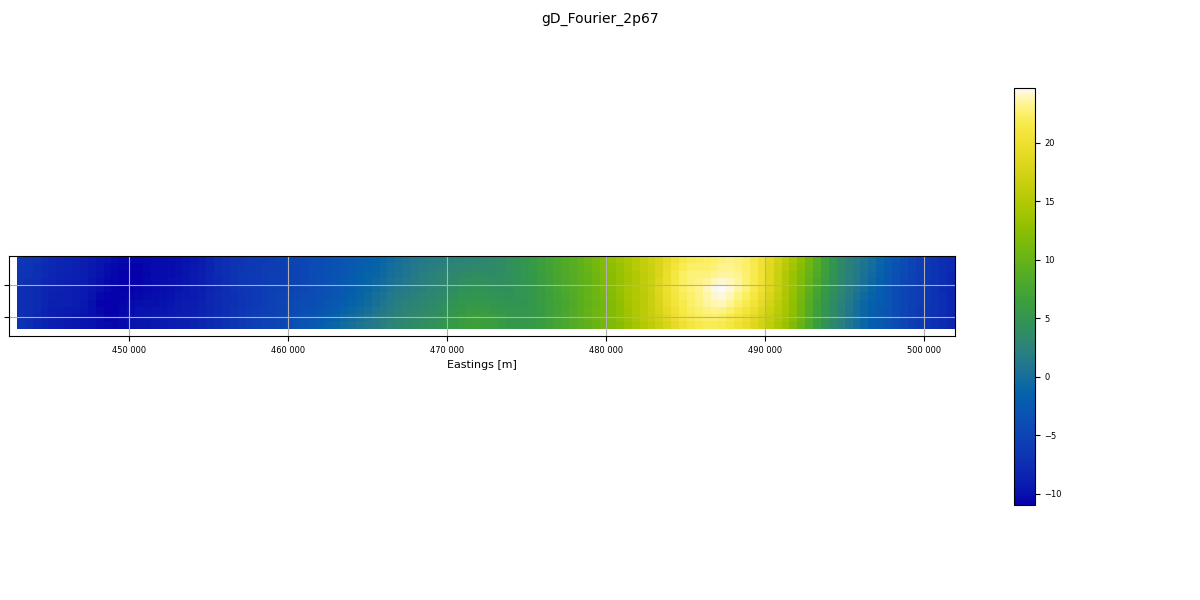

RMS of result = 10.23 µm/s/s


In [6]:
z_chans = ['Bearing', 'CLEARANCE', 'DTM', 'FLIGHT', 'GDD_Fourier_2p67', 'NumSats',
           'T_DD', 'Time_1980', 'gD_Fourier_2p67']
mr_chans = ['Bearing']
d1_chans = ['FLIGHT', 'Time_1980']
qc.grid_n_image(canobieHDF_file, z_chans, 500.0, mr_chans=mr_chans, d1_chans=d1_chans, method='scipy')

Gridding and imaging Bearing
6 lines; total number of fids in whizz file = 48583.
    Bearing (mr): min = -10.986009852216796, max = 6.113990147783227.
Processing (x, y, z) = (EASTING, NORTHING, MR_Bearing). MR_Bearing in degrees.


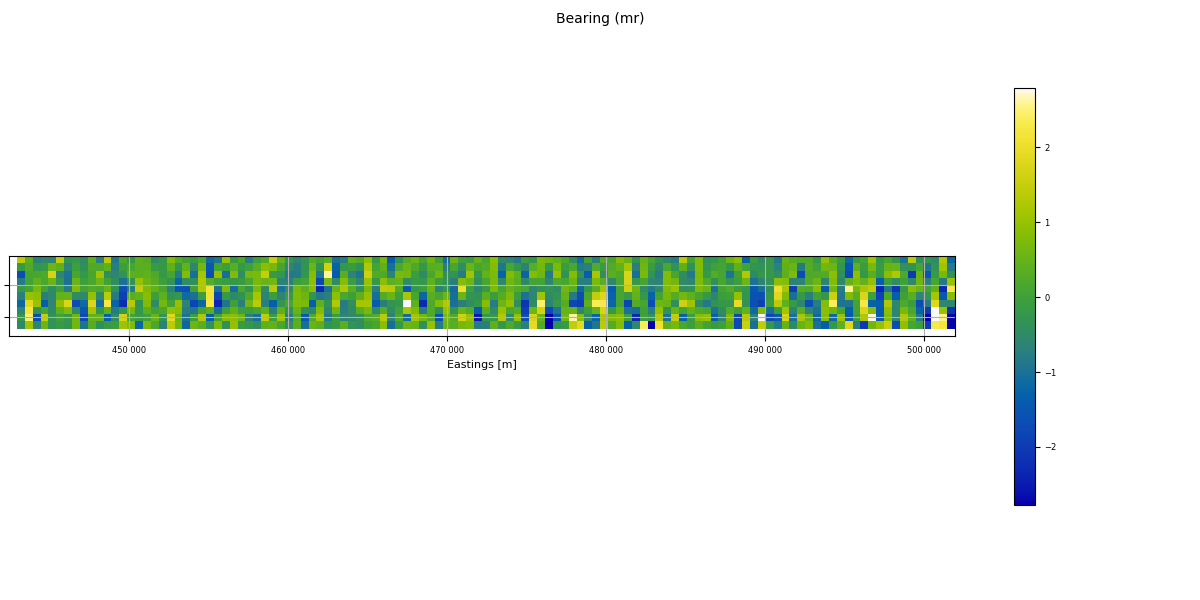

RMS of result = 0.93 degrees
Gridding and imaging CLEARANCE
6 lines; total number of fids in whizz file = 48583.
    CLEARANCE: min = 66.655, max = 329.044.
Processing (x, y, z) = (EASTING, NORTHING, CLEARANCE). CLEARANCE in metre.


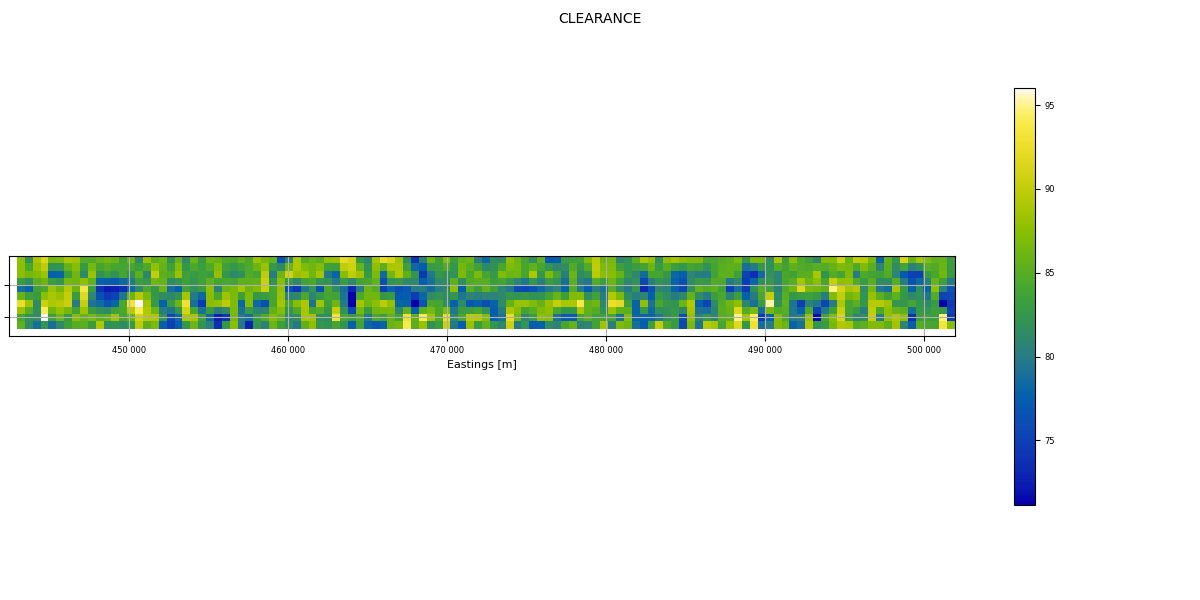

RMS of result = 4.14 metre
Gridding and imaging DTM
6 lines; total number of fids in whizz file = 48583.
    DTM: min = 47.9, max = 76.9.
Processing (x, y, z) = (EASTING, NORTHING, DTM). DTM in metre.


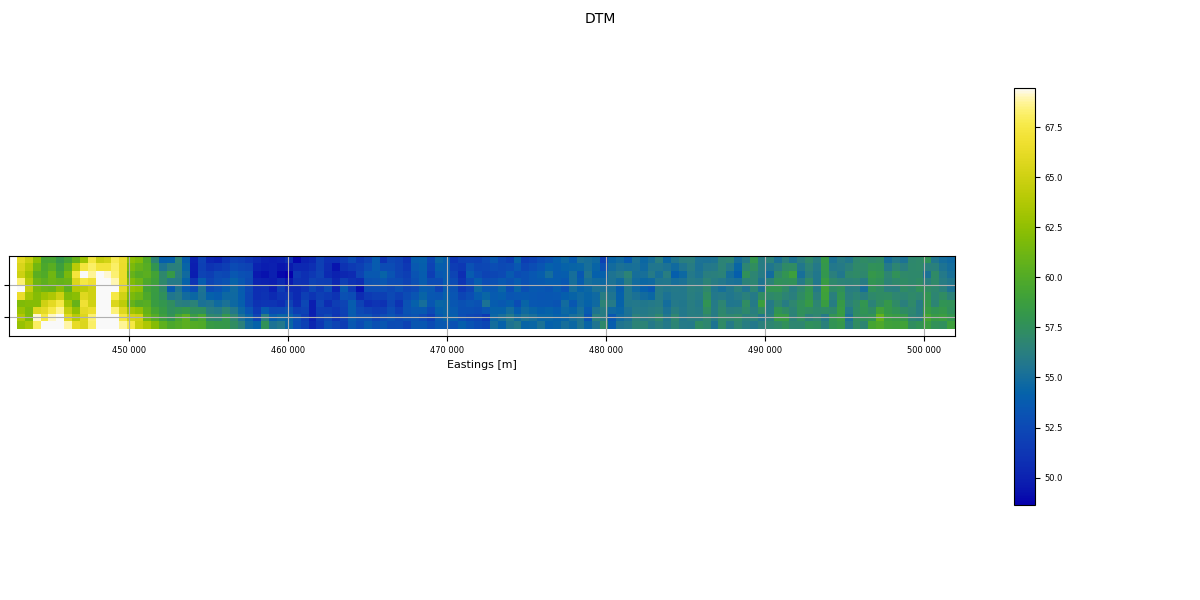

RMS of result = 4.43 metre
Gridding and imaging FLIGHT
6 lines; total number of fids in whizz file = 48583.
    FLIGHT (d1): min = 0.0, max = 0.0.
Processing (x, y, z) = (EASTING, NORTHING, D1_FLIGHT). D1_FLIGHT in .


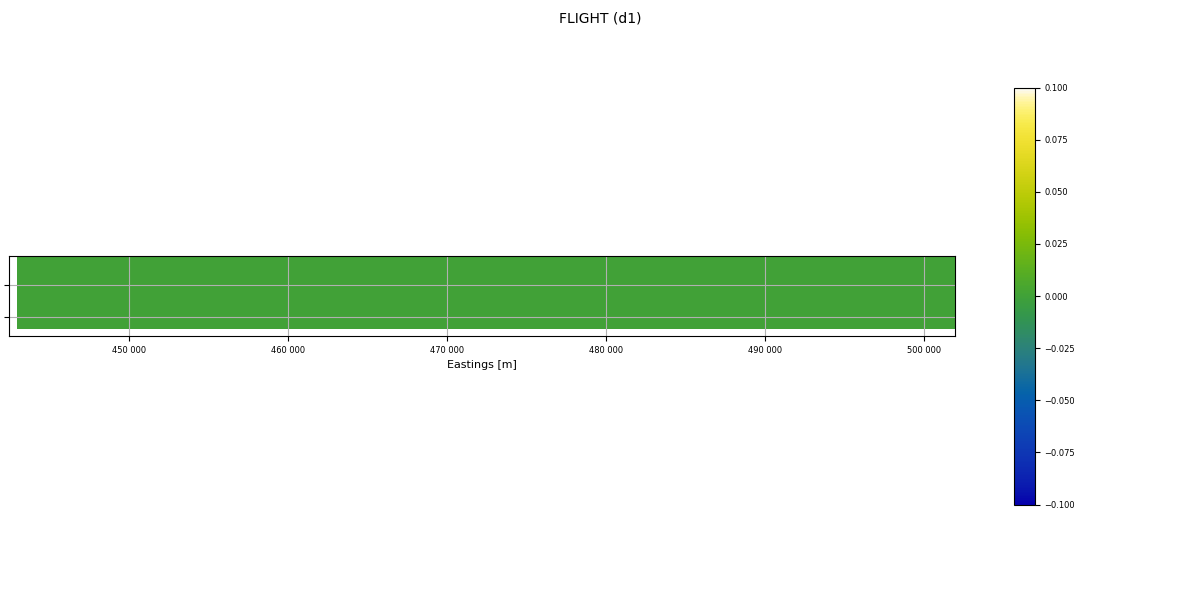

RMS of result = 0.00 
Gridding and imaging GDD_Fourier_2p67
6 lines; total number of fids in whizz file = 48583.
    GDD_Fourier_2p67: min = -29.47, max = 67.3.
Processing (x, y, z) = (EASTING, NORTHING, GDD_Fourier_2p67). GDD_Fourier_2p67 in eotvos.


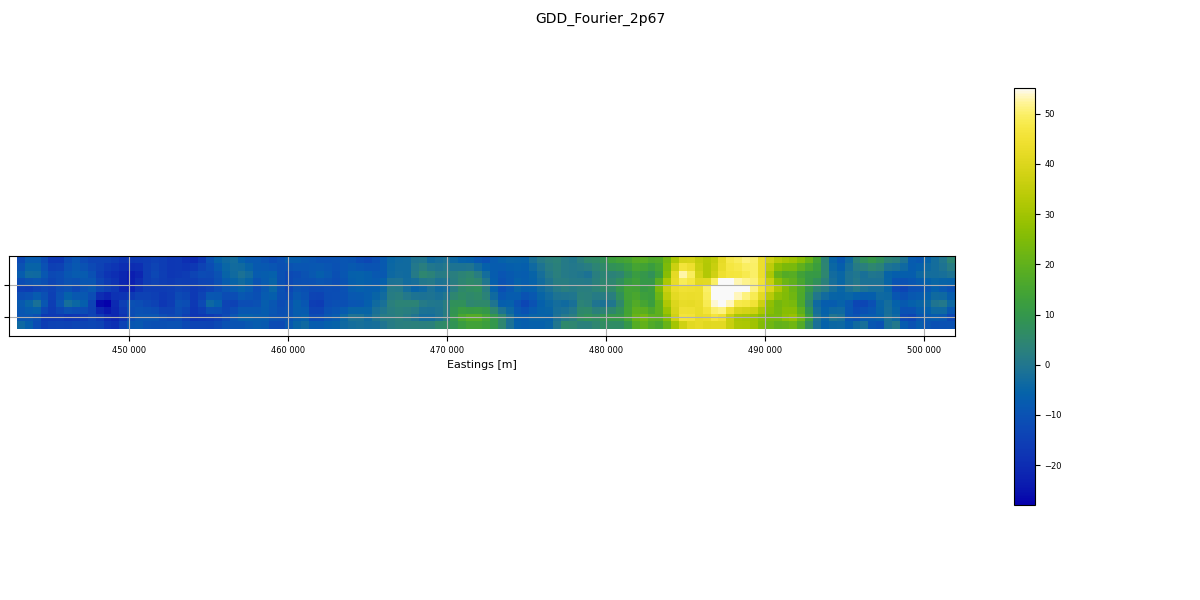

RMS of result = 17.85 eotvos
Gridding and imaging NumSats
6 lines; total number of fids in whizz file = 48583.
    NumSats: min = 8.0, max = 15.0.
Processing (x, y, z) = (EASTING, NORTHING, NumSats). NumSats in .


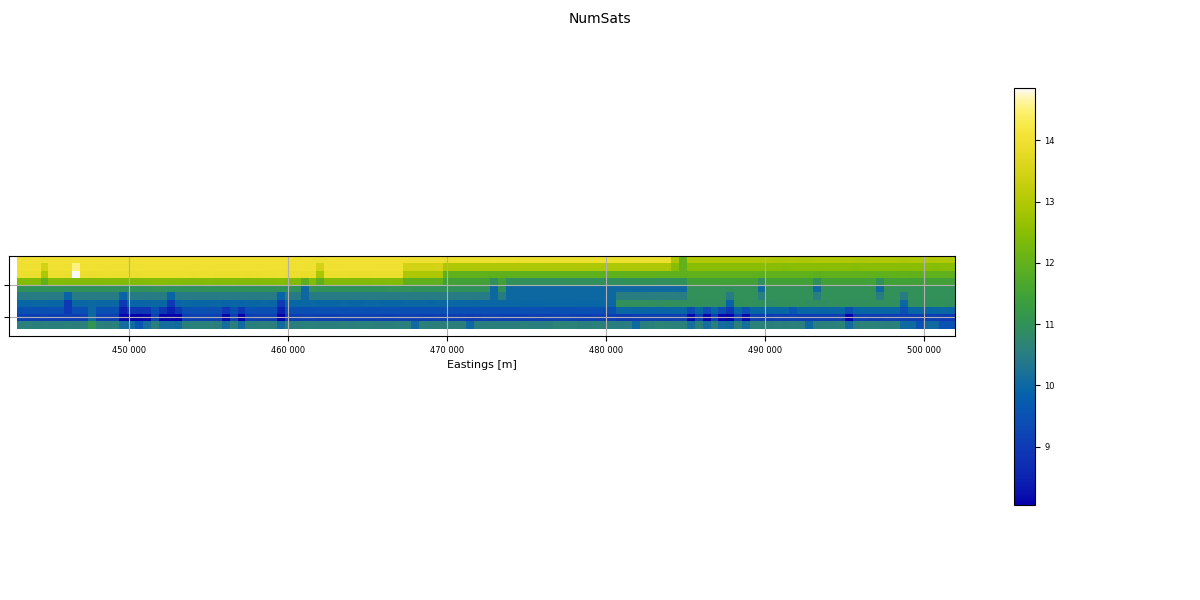

RMS of result = 1.61 
Gridding and imaging T_DD
6 lines; total number of fids in whizz file = 48583.
    T_DD: min = -4.84, max = 14.26.
Processing (x, y, z) = (EASTING, NORTHING, T_DD). T_DD in eotvos.


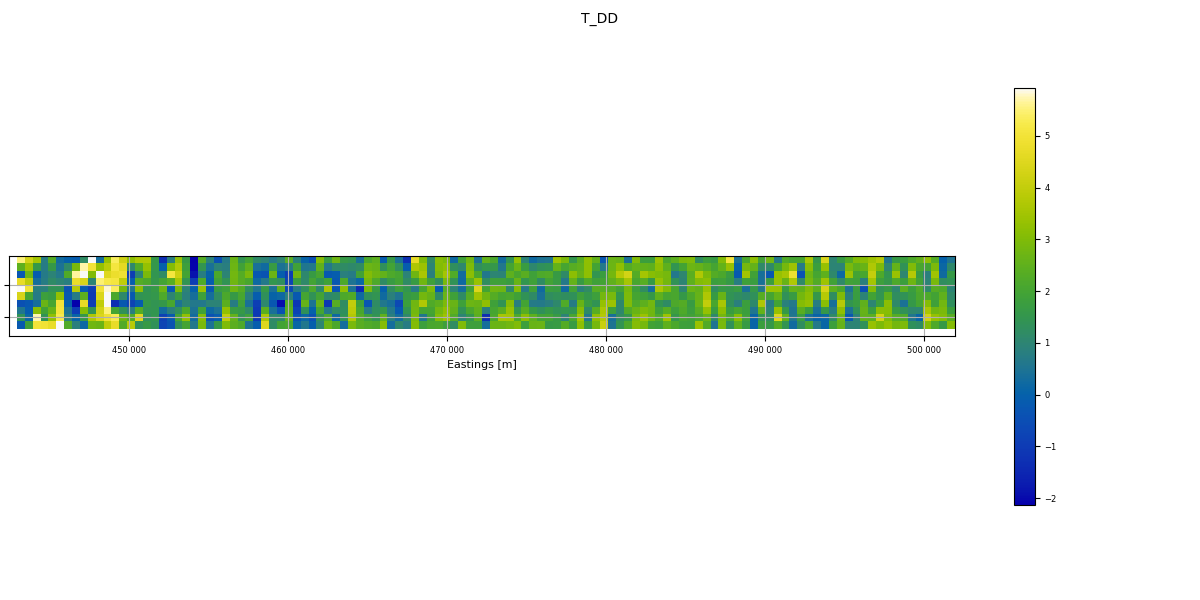

RMS of result = 1.34 eotvos
Gridding and imaging Time_1980
6 lines; total number of fids in whizz file = 48583.
    Time_1980 (d1): min = 0.125, max = 0.12600016593933105.
Processing (x, y, z) = (EASTING, NORTHING, D1_Time_1980). D1_Time_1980 in seconds.


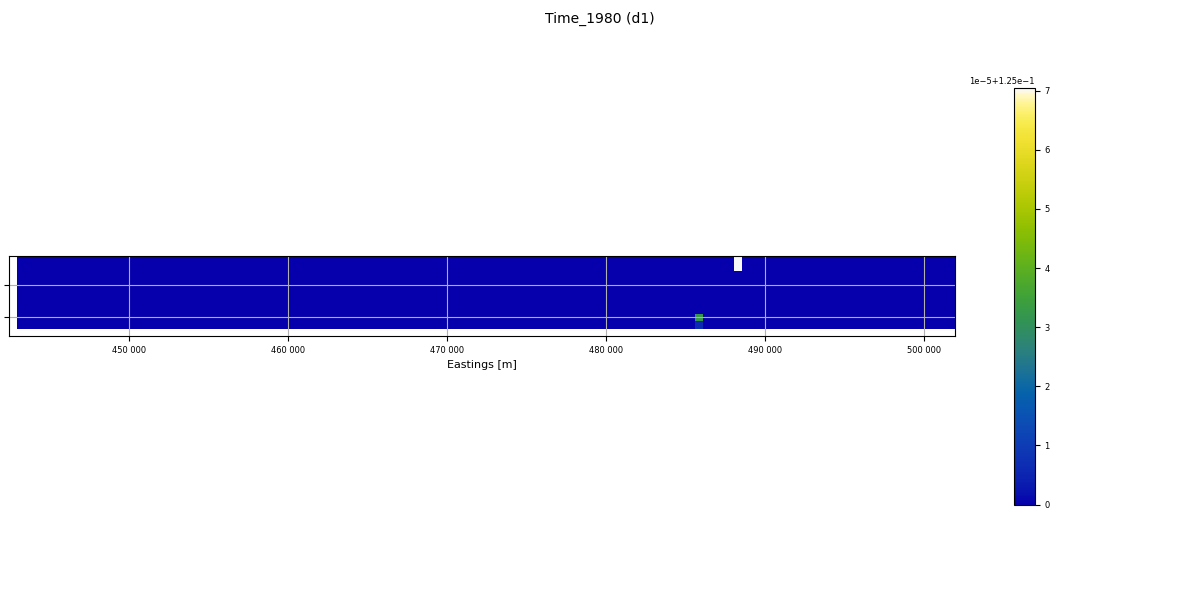

RMS of result = 0.00 seconds
Gridding and imaging gD_Fourier_2p67
6 lines; total number of fids in whizz file = 48583.
    gD_Fourier_2p67: min = -10.92, max = 24.71.
Processing (x, y, z) = (EASTING, NORTHING, gD_Fourier_2p67). gD_Fourier_2p67 in µm/s/s.


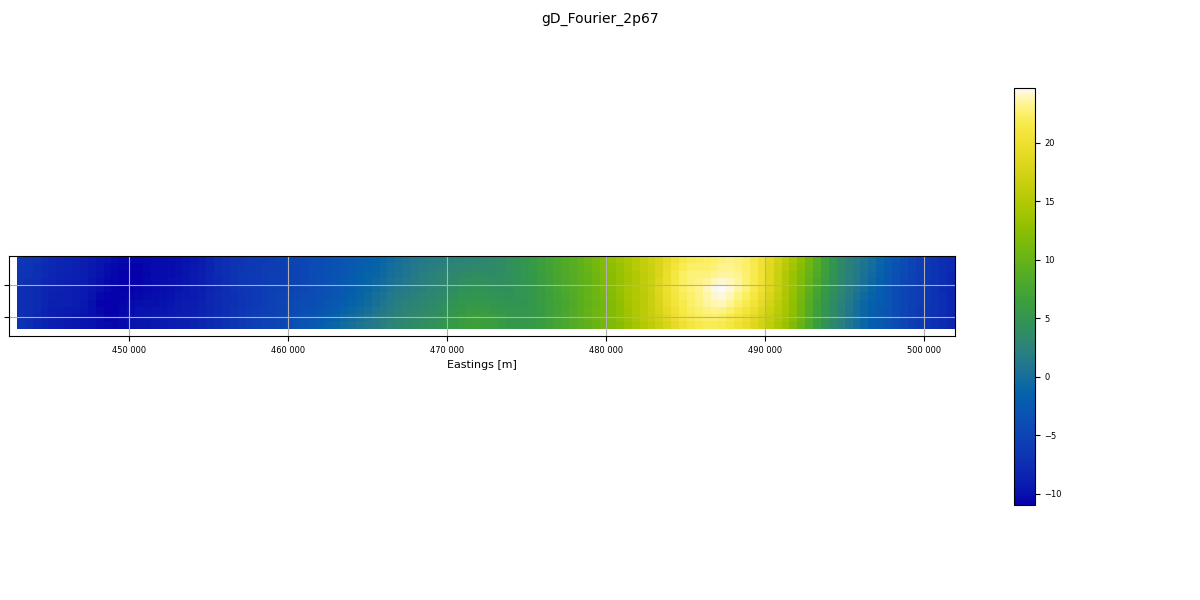

RMS of result = 10.23 µm/s/s


In [5]:
z_chans = ['Bearing', 'CLEARANCE', 'DTM', 'FLIGHT', 'GDD_Fourier_2p67', 'NumSats',
           'T_DD', 'Time_1980', 'gD_Fourier_2p67']
mr_chans = ['Bearing']
d1_chans = ['FLIGHT', 'Time_1980']
qc.grid_n_image(canobieHDF_file, z_chans, 500.0, mr_chans=mr_chans, d1_chans=d1_chans)

## Time of finish

In [ ]:
print(datetime.datetime.now())
print(datetime.datetime.now() - start)